In [4]:
import json
import random
import pickle
import numpy as np
import nltk
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
print("libraries load success.")

libraries load success.


In [5]:
nltk.download('punkt')
nltk.download('punkt_tab')   # needed in newer nltk versions
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()
print("NLTK data ready.")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\xiang\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\xiang\AppData\Roaming\nltk_data...


NLTK data ready.


[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\xiang\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\xiang\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## Dataset

In [8]:
intents = {
  "intents": [
    {
      "tag": "greeting",
      "patterns": ["Hi", "Hello", "Hey", "Good morning", "Good evening", "Is anyone there?", "Hey there", "Hi there", "Yo", "Hiya", "Greetings"],
      "responses": [
        "Hey, I'm glad you're here. I'm here to listen and help you understand and manage burnout — what's on your mind today?",
        "Hi there. However you're doing today, I'm ready to listen. What would you like to talk about?"
      ]
    },
    {
      "tag": "goodbye",
      "patterns": ["Bye", "Goodbye", "See you later", "I have to go", "Talk to you later", "Thanks bye", "Gotta go", "I'll talk to you soon", "See ya"],
      "responses": [
        "Take care of yourself, okay? Remember, it's okay to ask for help when you need it. I'm here whenever you want to talk again.",
        "Goodbye for now. Be gentle with yourself — come back anytime you want to talk about how you're feeling."
      ]
    },
    {
      "tag": "thanks",
      "patterns": ["Thanks", "Thank you", "That helps", "Thanks a lot", "Appreciate it", "Thanks for listening", "That was helpful, thank you"],
      "responses": [
        "You're very welcome. I'm really glad that helped.",
        "Anytime. Taking the time to check in on yourself like this matters."
      ]
    },
    {
      "tag": "how_are_you",
      "patterns": ["How are you?", "How are you doing?", "How's it going?", "You okay?", "How have you been?", "What's up with you?", "How's your day?"],
      "responses": ["I'm just a program so I don't get burned out myself, but thanks for asking — that's kind of you. I'm more curious how *you're* doing today?"]
    },
    {
      "tag": "bot_name",
      "patterns": ["What is your name?", "Do you have a name?", "What should I call you?", "Who am I talking to?", "What do I call this bot?", "Does this chatbot have a name?", "Introduce yourself", "Can you tell me your name?"],
      "responses": ["You can call me the Burnout Support Bot. I'm here to listen and help you learn more about burnout, whenever you need it."]
    },
    {
      "tag": "bot_identity",
      "patterns": ["Who are you?", "What can you do?", "What is this chatbot?", "Are you a real person?", "What are you?", "Tell me about yourself", "What kind of bot are you?", "What is your purpose?"],
      "responses": [
        "I'm a chatbot here to support you around burnout — I'm not a real person or a therapist, but I can listen, share reliable information, and point you toward help when you need more than I can offer. What's going on for you?"
      ]
    },
    {
      "tag": "venting",
      "patterns": [
        "I'm so stressed", "I can't handle this anymore", "I'm exhausted",
        "This is too much for me", "I feel overwhelmed", "I'm really struggling right now",
        "Everything feels like too much", "I'm tired of everything", "I just need to vent",
        "Work is killing me", "I feel like I'm drowning", "I don't know how much more I can take",
        "My boss scolded me", "My boss is angry at me", "I got yelled at by my boss",
        "I feel so lonely", "I feel alone", "I don't know why I feel so sad",
        "Yes I get angry from my boss", "I already told you how I feel", "I feel angry and sad",
        "I feel down", "I feel empty", "I don't have anyone", "I feel stuck"
      ],
      "responses": [
        "That sounds really heavy to be carrying. I'm glad you said something — you don't have to hold it in. Do you want to tell me a bit more about what's been going on, or would it help to look at a few things that might ease it right now?",
        "I hear you, and that sounds exhausting. It makes sense you'd feel that way if this has been building up. What's been the hardest part lately?",
        "That's a lot to be dealing with. Thank you for sharing it with me — I'm listening. What do you feel like you need most right now, someone to listen or some practical ideas?",
        "It sounds like things have really piled up on you. That's genuinely hard. Take your time — I'm here."
      ]
    },
    {
      "tag": "burnout_definition",
      "patterns": [
        "What is burnout?", "Can you explain burnout?", "Define burnout",
        "What does burnout mean?", "I keep hearing about burnout, what is it?",
        "What is workplace burnout?", "Explain what burnout is",
        "Give me a definition of burnout", "What exactly is burnout", "Can you describe burnout"
      ],
      "responses": [
        "Good question — burnout is more than just being tired. The World Health Organization describes it as a syndrome from chronic workplace stress that hasn't been successfully managed, showing up as energy depletion, feeling mentally distant from your job, and reduced effectiveness. Does that sound like something you've been feeling?"
      ]
    },
    {
      "tag": "burnout_symptoms",
      "patterns": [
        "What are the symptoms of burnout?", "How do I know if I'm burned out?",
        "Signs of burnout", "What does burnout feel like?",
        "Am I experiencing burnout?", "How can I tell if I have burnout?",
        "What are common burnout signs?", "How do I recognise burnout in myself",
        "What are the warning signs of burnout", "List some burnout symptoms"
      ],
      "responses": [
        "That's a really important thing to check in on. Common signs include feeling emotionally drained, becoming more cynical or detached from your work, trouble concentrating, sleep issues, and irritability. Do any of these feel familiar to what you've been going through?"
      ]
    },
    {
      "tag": "burnout_causes",
      "patterns": [
        "What causes burnout?", "Why do people get burned out?",
        "What leads to burnout?", "Causes of workplace burnout",
        "What are the risk factors for burnout?", "Why am I feeling burned out?",
        "What triggers burnout", "What contributes to burnout", "What's behind burnout", "Why does burnout happen"
      ],
      "responses": [
        "It's rarely just one thing. Research points to excessive workload, long hours, poor work-life balance, lack of support, and ineffective leadership as common causes — especially when stress builds up with little time to recover. Does any of that resonate with your situation?"
      ]
    },
    {
      "tag": "burnout_vs_stress",
      "patterns": [
        "Is burnout the same as stress?", "What's the difference between stress and burnout?",
        "How is burnout different from being stressed?", "Stress vs burnout",
        "Isn't burnout just stress?", "How do you tell stress and burnout apart",
        "Is being stressed the same as being burned out", "Difference between stressed and burned out"
      ],
      "responses": [
        "Great question, people mix these up a lot. Stress is usually about feeling overwhelmed by pressure that can ease once things calm down. Burnout is more of a long-term state from stress that's gone unmanaged for a while — it includes exhaustion, cynicism, and reduced effectiveness that doesn't just lift after a weekend off."
      ]
    },
    {
      "tag": "burnout_stages",
      "patterns": [
        "What are the stages of burnout?", "How does burnout progress?",
        "Does burnout happen gradually?", "Phases of burnout",
        "How does burnout develop over time", "Are there levels of burnout",
        "Does burnout get worse over time", "What's the progression of burnout"
      ],
      "responses": [
        "It usually creeps up gradually rather than hitting all at once — often starting with overwork and high drive, moving into chronic stress and lower satisfaction, then emotional exhaustion and detachment, and eventually full burnout if it's not addressed. The good news is catching it early makes a real difference."
      ]
    },
    {
      "tag": "self_help_strategies",
      "patterns": [
        "How can I manage burnout?", "What can I do about burnout?",
        "How do I recover from burnout?", "Tips to reduce burnout",
        "How can I cope with stress at work?", "What self-care strategies help with burnout?",
        "How to prevent burnout?", "What are some coping strategies", "How do I deal with burnout", "Any tips for managing burnout"
      ],
      "responses": [
        "There's no single fix, but a few things tend to help: mindfulness, regular movement, enough sleep, setting boundaries at work, taking real breaks, and keeping communication open with your team. Want me to go deeper into any one of these?"
      ]
    },
    {
      "tag": "mindfulness_detail",
      "patterns": ["mindfulness", "tell me about mindfulness", "how do I practice mindfulness", "more about mindfulness", "what is mindfulness", "how does mindfulness help", "mindfulness practice", "can you explain mindfulness more"],
      "responses": [
        "Mindfulness means gently focusing on the present moment instead of getting swept up in worries about work or the future. A simple way to start: spend 5 minutes just noticing your breath, or your surroundings, without trying to change anything. Apps or short guided audio can help if you're new to it."
      ]
    },
    {
      "tag": "exercise_detail",
      "patterns": ["exercise", "regular movement", "tell me about exercise", "physical activity", "movement", "how does exercise help with burnout", "what kind of exercise helps", "tell me more about movement"],
      "responses": [
        "Regular movement doesn't need to mean an intense workout — even a 20-30 minute walk most days can lower stress hormones and improve your mood. The key is consistency over intensity, so pick something you'll actually keep doing."
      ]
    },
    {
      "tag": "boundaries_detail",
      "patterns": ["boundaries", "setting boundaries", "tell me about boundaries", "how to set boundaries at work", "work boundaries", "how do I set limits at work", "tell me more about boundaries", "how can I protect my time"],
      "responses": [
        "Setting boundaries could mean deciding on a firm time you stop checking emails, saying no to tasks outside your capacity, or blocking focus time on your calendar. It helps to communicate these boundaries clearly rather than assuming others will guess them."
      ]
    },
    {
      "tag": "breaks_detail",
      "patterns": ["breaks", "taking breaks", "tell me about breaks", "how to take breaks", "rest breaks", "why are breaks important", "tell me more about taking breaks", "how often should I take breaks"],
      "responses": [
        "Short, regular breaks — even 5-10 minutes every hour or two — can prevent the kind of mental fatigue that builds into burnout. Stepping away from your screen, stretching, or getting some fresh air works better than pushing through non-stop."
      ]
    },
    {
      "tag": "communication_detail",
      "patterns": ["communication", "team communication", "tell me about communication", "keeping communication open", "talking to my team", "how does communication help with burnout", "tell me more about team communication", "why is communication important at work"],
      "responses": [
        "Keeping communication open means letting your team or manager know early when your workload feels unmanageable, rather than waiting until you're overwhelmed. Regular check-ins, even brief ones, can help catch issues before they build up."
      ]
    },
    {
      "tag": "early_detection",
      "patterns": [
        "How can I catch burnout early?", "What are early warning signs of burnout?",
        "How to detect burnout before it gets worse?", "Early symptoms of burnout",
        "How do I notice burnout before it's serious", "What should I watch out for early on",
        "Can burnout be caught early", "Signs to watch for before burnout gets bad"
      ],
      "responses": [
        "Catching it early really does help. Watch for things like persistent tiredness, dropping motivation, and creeping irritability — noticing these and adjusting early, like easing your workload or reaching out for support, can stop it from getting more serious."
      ]
    },
    {
      "tag": "work_life_balance",
      "patterns": [
        "How do I improve my work-life balance?", "How can I balance work and personal life?",
        "Tips for work-life balance", "How to stop work from taking over my life?",
        "How do I separate work and home life", "My work is taking over my personal life",
        "How can I protect my personal time", "Any advice for work-life balance"
      ],
      "responses": [
        "That balance is tough to protect, but worth it. Try setting clear boundaries on work hours, stepping away from emails after hours, scheduling real personal time, and telling your team what your limits are. What does your current routine look like?"
      ]
    },
    {
      "tag": "talking_to_manager",
      "patterns": [
        "How do I talk to my manager about burnout?", "Should I tell my boss I'm burned out?",
        "How to bring up burnout at work?", "Talking to my supervisor about stress",
        "How do I approach my manager about my workload", "Should I be honest with my boss about burnout",
        "How to ask my manager for support", "I'm scared to tell my boss I'm struggling"
      ],
      "responses": [
        "That can feel intimidating, but it's often worth it. It can help to bring specific examples of how your workload is affecting you, focus the conversation on possible solutions, and ask for a private, calm moment to talk. Organisational support genuinely makes a difference in reducing burnout."
      ]
    },
    {
      "tag": "student_burnout",
      "patterns": [
        "Can students get burnout?", "Is burnout only for workers?",
        "Do students experience burnout too?", "Academic burnout",
        "Can university students get burned out", "Is burnout a thing for students",
        "I'm a student and I feel burned out", "Does school cause burnout"
      ],
      "responses": [
        "Yes, definitely — burnout isn't just a workplace thing. Students can experience it too, from ongoing academic pressure, heavy workloads, and a poor study-life balance, and it can look a lot like exhaustion, detachment, and losing motivation for schoolwork."
      ]
    },
    {
      "tag": "remote_work_burnout",
      "patterns": [
        "Does remote work cause burnout?", "Can working from home lead to burnout?",
        "Is burnout worse when working remotely?", "Remote work and burnout",
        "I work from home and feel burned out", "Does working from home make burnout worse",
        "Is WFH linked to burnout", "How does remote work affect burnout"
      ],
      "responses": [
        "Yes, remote work can contribute to burnout, especially when boundaries between work and personal life become blurred, working hours extend informally, and in-person social support is reduced. Setting a clear daily schedule and dedicated workspace can help."
      ]
    },
    {
      "tag": "burnout_statistics",
      "patterns": [
        "How common is burnout?", "How many people experience burnout?",
        "Is burnout a common problem?", "Burnout statistics",
        "How widespread is burnout", "What percentage of people experience burnout",
        "Is burnout common in the workplace", "How prevalent is burnout"
      ],
      "responses": [
        "You're definitely not alone in this — burnout is recognised as a major occupational health concern worldwide, especially in high-stress fields like healthcare, and it's consistently linked to lower job satisfaction and people leaving their jobs."
      ]
    },
    {
      "tag": "breathing_exercise",
      "patterns": [
        "Can you guide me through a breathing exercise?", "Teach me a relaxation technique",
        "I need to calm down", "Give me a breathing exercise for stress",
        "Help me relax", "Can you walk me through breathing exercises",
        "I need a quick way to calm down", "Guide me through deep breathing"
      ],
      "responses": [
        "Sure, let's slow things down together. Breathe in slowly through your nose for 4 seconds, hold for 4, then breathe out slowly through your mouth for 6 seconds. Repeat that 4 or 5 times. Take your time — how do you feel?"
      ]
    },
    {
      "tag": "time_management_tips",
      "patterns": [
        "How can I manage my time better?", "Tips for managing my workload",
        "How to prioritise tasks?", "I have too much to do, help",
        "How do I organise my tasks better", "I can't keep up with my workload",
        "Any advice for time management", "How do I stop feeling behind on everything"
      ],
      "responses": [
        "That feeling of too much at once is draining. Try breaking tasks into smaller steps, tackling the most important ones first, keeping a simple to-do list, and building in short breaks between tasks rather than multitasking straight through."
      ]
    },
    {
      "tag": "sleep_tips",
      "patterns": [
        "How can I sleep better?", "I have trouble sleeping because of stress",
        "Tips for better sleep", "How to improve sleep quality?", "sleep",
        "I can't sleep because of work stress", "How do I fix my sleep schedule",
        "Any advice for better sleep", "I keep waking up at night from stress"
      ],
      "responses": [
        "Stress and bad sleep tend to feed each other, so this is worth tackling. Try a consistent sleep schedule, less screen time before bed, cutting back caffeine in the afternoon, and a calming wind-down routine. Good sleep really is one of the bigger levers for recovering from burnout."
      ]
    },
    {
      "tag": "seek_professional_help",
      "patterns": [
        "When should I see a professional?", "Should I talk to a therapist?",
        "Do I need to see a doctor for burnout?", "When is burnout serious enough for help?",
        "Where can I get professional help?", "Should I see a counsellor?",
        "I think I'm depressed", "I have depression", "I think I might be depressed",
        "I can't take it anymore", "How do I find a therapist", "Is it time to get professional help"
      ],
      "responses": [
        "If what you're feeling is severe, sticking around, or getting in the way of daily life, it's worth reaching out to a doctor, counsellor, or mental health professional — that's not a sign of failure, it's a smart step. I can share information, but I'm not a substitute for that kind of support."
      ]
    },
    {
      "tag": "crisis_support",
      "patterns": [
        "I can't cope anymore", "I feel hopeless", "I don't want to go on like this",
        "I feel like giving up", "I'm at my breaking point", "I don't see the point anymore",
        "I feel completely defeated", "I have nothing left in me", "I don't know how to keep going"
      ],
      "responses": [
        "I'm really sorry you're feeling this way, and I'm glad you told me. I'm not able to give you the level of support you need right now, but please reach out to a mental health professional or a crisis helpline in your area as soon as you can — you don't have to go through this alone."
      ]
    },
    {
      "tag": "crisis_self_harm",
      "patterns": [
        "I wanna die", "I want to die", "I want to end my life", "I want to kill myself",
        "I don't want to live anymore", "I want to end it all", "I want to hurt myself",
        "I'm thinking about suicide", "I feel like ending it", "I don't want to be alive anymore",
        "I've been thinking about hurting myself"
      ],
      "responses": [
        "I'm really sorry you're going through this. Your safety is important. I’m not able to provide crisis counselling, but please seek immediate support from someone you trust or a qualified mental health professional. If you think you may hurt yourself or are in immediate danger, contact your local emergency service or go to the nearest emergency department."
      ]
    },
    {
      "tag": "crisis_harm_others",
      "patterns": [
        "I want to kill him", "I want to kill her", "I want to kill them", "I want to hurt someone",
        "I want to hurt him", "I want to hurt her", "I feel like attacking someone", "I want to kill my boss",
        "I feel like I could hurt someone", "I want to hurt my coworker", "I feel like lashing out violently"
      ],
      "responses": [
        "It sounds like you may be experiencing very intense emotions. I can't help with harming another person. Please move away from anyone you might hurt, avoid weapons or other dangerous objects, and seek immediate help from emergency services or a qualified professional."
      ]
    },
    {
      "tag": "crisis_passive_ideation",
      "patterns": [
        "I just want to sleep until I don't wake up", "I wish I wouldn't wake up",
        "I want to go to sleep and never wake up", "I don't want to wake up tomorrow",
        "I just want to sleep forever", "I wish I could just not wake up",
        "I hope I don't wake up in the morning", "Part of me hopes I just don't wake up",
        "I wouldn't mind if I didn't wake up", "I keep wishing I wouldn't wake up"
      ],
      "responses": [
        "It sounds like you're going through a very difficult time. Thoughts about not wanting to wake up can be a sign that you need immediate support. Please reach out to someone you trust and a qualified mental health professional. If you feel you may hurt yourself or are in immediate danger, seek emergency help now."
      ]
    },
    {
      "tag": "low_self_worth",
      "patterns": [
        "I feel so worthless", "No one likes me", "I can't do anything right", "I am so useless",
        "Nothing makes sense anymore", "I feel like a failure", "I feel like I'm not good enough",
        "I feel like I let everyone down", "I don't feel good enough for this job"
      ],
      "responses": [
        "That's a painful way to feel, and I don't take it lightly. Burnout can really distort how we see ourselves and our own worth — it's not always an accurate reflection of reality. What's been making you feel this way lately?"
      ]
    },
    {
      "tag": "anxious",
      "patterns": [
        "I feel so anxious", "I'm anxious about this", "I feel nervous and on edge",
        "I can't stop worrying", "I feel panicky", "My mind won't stop racing",
        "I feel jittery and on edge", "I'm anxious about work all the time"
      ],
      "responses": [
        "That sounds uncomfortable to sit with. When anxiety creeps in like that, grounding yourself in the present moment can help — want me to walk you through a quick breathing exercise, or would you rather talk through what's on your mind?"
      ]
    },
    {
      "tag": "reluctant_to_share",
      "patterns": [
        "I don't want to talk about it", "I can't bring myself to open up",
        "I'd rather not say", "Just leave me alone", "I don't feel like talking right now",
        "I'm not ready to talk about this", "Can we not talk about this right now", "I don't really want to get into it"
      ],
      "responses": [
        "That's completely okay — you don't owe me an explanation. I'm here whenever you feel ready, and there's no pressure either way."
      ]
    },
    {
      "tag": "bot_limitation",
      "patterns": [
        "You don't understand me", "You're just a robot, how would you know",
        "You can't possibly know what I'm going through", "Nobody understands me",
        "You're not a real person so you don't get it", "How could an AI understand this",
        "You don't really get what I'm feeling", "You're just a program, this isn't real help"
      ],
      "responses": [
        "You're right, I can't fully understand from lived experience the way another person could — that's a fair thing to point out. What I can do is listen without judgment and help you think things through. And for a lot of this, talking to someone who knows you personally, or a professional, is genuinely worth doing alongside chatting with me."
      ]
    },
    {
      "tag": "casual_ack",
      "patterns": ["ok", "okay", "yes", "no", "nice", "sure", "fine", "not really", "whatever", "hmm", "alright", "I guess"],
      "responses": [
        "I'm listening — go on, whenever you're ready.",
        "Take your time. What's on your mind?"
      ]
    },
    {
      "tag": "conversation_repair",
      "patterns": [
        "You already told me that", "You already said that", "Why are you repeating yourself?",
        "I already told you that", "You just said that", "That doesn't make sense",
        "Wrong answer", "That's not what I meant", "You're not understanding me", "That's not right",
        "That's not what I asked", "I don't think that answered my question"
      ],
      "responses": [
        "Sorry about that, thanks for pointing it out. Could you tell me a bit more about what you're looking for, or rephrase it for me?",
        "My mistake — let's try that again. What would be most helpful to focus on right now?"
      ]
    },
    {
      "tag": "topic_change",
      "patterns": [
        "Can we talk about something else?", "I don't want to talk about this anymore",
        "Let's change the subject", "Can we move on from this?",
        "I'd rather talk about something else", "Let's talk about a different topic",
        "Can we switch topics", "Moving on from that"
      ],
      "responses": [
        "Of course. What would you like to talk about instead — maybe symptoms, self-help strategies, or something else on your mind?"
      ]
    },
    {
      "tag": "isolation",
      "patterns": [
        "I don't have any friends", "I feel so isolated", "I have no one to talk to",
        "I feel disconnected from people", "I feel really alone in this",
        "I've been pulling away from everyone", "I don't talk to anyone anymore", "I feel cut off from people"
      ],
      "responses": [
        "That sounds really hard to carry on your own. Feeling isolated can make burnout feel even heavier. Is there anyone in your life, even just one person, you'd feel okay reaching out to?"
      ]
    },
    {
      "tag": "closing_conversation",
      "patterns": [
        "That's all", "I don't have anything more to say", "Nothing else for now",
        "That's all I wanted to say", "That's all for today", "I think I'm done for now",
        "That covers it for today", "I'm good for now, thanks"
      ],
      "responses": [
        "Thanks for sharing what you did today. I'm here whenever you want to pick this back up."
      ]
    },
    {
      "tag": "mental_health_definition",
      "patterns": ["What is mental health?", "Define mental health", "What does mental health mean?", "Can you explain mental health", "What's included in mental health", "How would you define mental health", "What does good mental health look like", "Tell me about mental health in general"],
      "responses": [
        "Mental health covers our emotional, psychological, and social well-being — it shapes how we think, feel, handle stress, and relate to others. Burnout is one specific way that chronic stress can affect it."
      ]
    },
    {
      "tag": "out_of_scope",
      "patterns": [
        "Do you know football?", "What's the weather today?", "Tell me a joke",
        "What's the capital of France?", "Can you recommend a movie?", "Who won the World Cup?",
        "Can you help me with my math homework?", "Write my essay for me", "What's 2 plus 2?",
        "Can you code a website for me?", "What's your favorite food?", "Tell me about the news today"
      ],
      "responses": [
        "That's outside what I'm built for — I'm focused specifically on burnout and stress-related support. I'm happy to help with things like burnout symptoms, causes, coping strategies, or just talking through how you're feeling. What's on your mind about that?",
        "I'm not really the right bot for that one — my whole focus is burnout and stress support. Is there something about how you've been feeling, or ways to manage burnout, I can help with instead?"
      ]
    }
  ]
}

with open('intents.json', 'w', encoding='utf-8') as f:
    json.dump(intents, f, indent=2)

print("intents.json created with", len(intents['intents']), "intents.")

intents.json created with 43 intents.


## Preprocess the Text

In [10]:
words = []
classes = []
documents = []
ignore_chars = ['?', '!', '.', ',']

for intent in intents['intents']:
    for pattern in intent['patterns']:
        word_list = nltk.word_tokenize(pattern)
        words.extend(word_list)
        documents.append((word_list, intent['tag']))
        if intent['tag'] not in classes:
            classes.append(intent['tag'])

# Lemmatize, lowercase, and remove duplicates/ignored characters
words = [lemmatizer.lemmatize(w.lower()) for w in words if w not in ignore_chars]
words = sorted(set(words))
classes = sorted(set(classes))

print(f"{len(documents)} training patterns")
print(f"{len(classes)} intents: {classes}")
print(f"{len(words)} unique lemmatized words in vocabulary")

398 training patterns
43 intents: ['anxious', 'bot_identity', 'bot_limitation', 'bot_name', 'boundaries_detail', 'breaks_detail', 'breathing_exercise', 'burnout_causes', 'burnout_definition', 'burnout_stages', 'burnout_statistics', 'burnout_symptoms', 'burnout_vs_stress', 'casual_ack', 'closing_conversation', 'communication_detail', 'conversation_repair', 'crisis_harm_others', 'crisis_passive_ideation', 'crisis_self_harm', 'crisis_support', 'early_detection', 'exercise_detail', 'goodbye', 'greeting', 'how_are_you', 'isolation', 'low_self_worth', 'mental_health_definition', 'mindfulness_detail', 'out_of_scope', 'reluctant_to_share', 'remote_work_burnout', 'seek_professional_help', 'self_help_strategies', 'sleep_tips', 'student_burnout', 'talking_to_manager', 'thanks', 'time_management_tips', 'topic_change', 'venting', 'work_life_balance']
436 unique lemmatized words in vocabulary


## Build the Training Data

Each sentence is converted into a bag-of-words vector

In [16]:
training = []
output_empty = [0] * len(classes)

for word_list, tag in documents:
    bag = []
    pattern_words = [lemmatizer.lemmatize(w.lower()) for w in word_list]
    for w in words:
        bag.append(1 if w in pattern_words else 0)

    output_row = list(output_empty)
    output_row[classes.index(tag)] = 1
    training.append([bag, output_row])

random.shuffle(training)

train_x = np.array([row[0] for row in training])
train_y = np.array([row[1] for row in training])

print("train_x shape:", train_x.shape)
print("train_y shape:", train_y.shape)

train_x shape: (398, 436)
train_y shape: (398, 43)


## Build and Train the Neural Network

In [21]:
model = Sequential()
model.add(Dense(128, input_shape=(len(train_x[0]),), activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(len(train_y[0]), activation='softmax'))

sgd = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])

history = model.fit(train_x, train_y, epochs=200, batch_size=5, verbose=1)

print("Training complete.")

C:\Users\xiang\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0377 - loss: 3.7755
Epoch 2/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0628 - loss: 3.6795
Epoch 3/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0905 - loss: 3.5857
Epoch 4/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1156 - loss: 3.4018
Epoch 5/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1884 - loss: 3.1587
Epoch 6/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2085 - loss: 2.9693
Epoch 7/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2739 - loss: 2.7395
Epoch 8/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3141 - loss: 2.4919
Epoch 9/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3819 - loss: 2.2296
Epoch 10/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3668 - loss: 2.1146
Epoch 11/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4271 - loss: 1.9755
Epoch 12/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy:

### Checking training progress (accuracy/loss curves)

Plotting accuracy and loss across epochs shows whether 200 epochs was actually a reasonable choice — if the curves flatten out (plateau) before reaching epoch 200, that's evidence training had converged and more epochs wouldn't help much. If they're still climbing/falling right at epoch 200, more epochs might improve things further. This plot is good evidence to include in your report (Section 3.3 or 4.1) to justify your epoch choice, rather than just picking 200 because it's a common default.

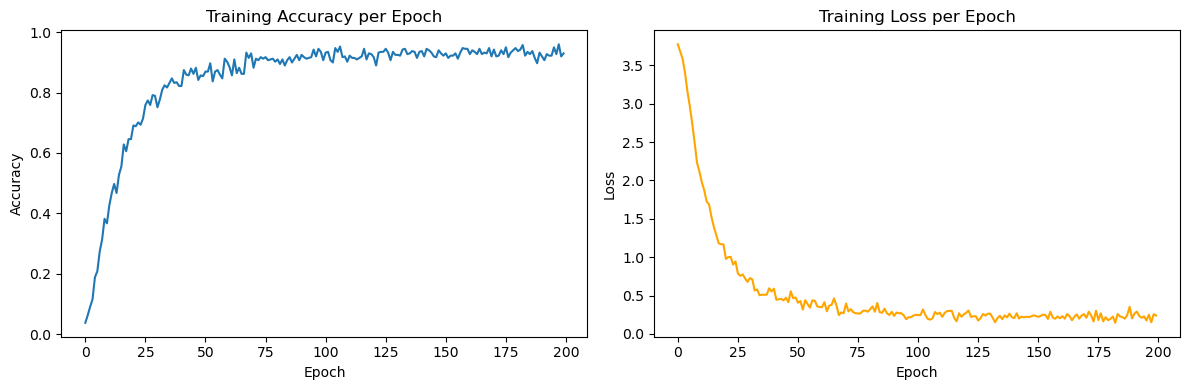

If both curves have flattened out by the end, 200 epochs was enough.


In [23]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'])
axes[0].set_title('Training Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')

axes[1].plot(history.history['loss'], color='orange')
axes[1].set_title('Training Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

print("If both curves have flattened out by the end, we can conclude that 200 epochs was enough.")

## Save the Model and Supporting Files

In [26]:
model.save('burnout_chatbot_model.h5')

with open('words.pkl', 'wb') as f:
    pickle.dump(words, f)

with open('classes.pkl', 'wb') as f:
    pickle.dump(classes, f)

print("Model and supporting files saved.")

Model and supporting files saved.


## Step 8: Prediction & Response Functions (with light context-awareness)

- `clean_up_sentence`: tokenizes + lemmatizes a new user message
- `bag_of_words`: converts it into the same bag-of-words format used for training
- `predict_class`: runs it through the model, returns the most likely intent(s) with confidence scores
- `get_response`: picks a response for the predicted intent

**Important limitation to know:** this model classifies each message **independently** — it has no memory of earlier turns in the conversation. That's normal for a basic Bag-of-Words intent classifier and is worth naming as a limitation in your report (Section 5.2). True memory would need a more advanced dialogue-management or LLM-based approach.

What we *can* do cheaply is add **context-awareness**: the bot keeps track of whether it's currently in a "supportive" conversation (e.g. after `venting`, `burnout_symptoms`, `talking_to_manager`, etc.). If the next message is ambiguous, it requires **much higher confidence** before letting the bot jump to `out_of_scope` or a completely different topic — instead of doing that, it stays supportive by default. This directly fixes the case where a vague follow-up (like "yes, I get angry from my boss") got misclassified as off-topic right after an emotional exchange.

**A third, safety-critical layer is added below:** for messages that suggest a risk of harm (to self or others), we do **not** rely on the neural network at all. Instead, a direct keyword check runs first and, if matched, immediately returns the appropriate crisis response — bypassing the ML classifier entirely. This is a deliberate design choice: for safety-critical situations, a simple, guaranteed keyword match is far more reliable than a probabilistic model that could occasionally miss the message or misclassify it. This is a good design point to mention explicitly in your report (e.g. Section 3.3 or as an ethical consideration).

In [28]:
ERROR_THRESHOLD = 0.25
OUT_OF_SCOPE_THRESHOLD = 0.55  # out_of_scope needs to be a lot more confident to fire mid-conversation

# Tags that count as an ongoing "supportive" conversation
SUPPORTIVE_TAGS = {
    "venting", "burnout_definition", "burnout_symptoms", "burnout_causes",
    "burnout_vs_stress", "burnout_stages", "self_help_strategies", "early_detection",
    "work_life_balance", "talking_to_manager", "student_burnout", "remote_work_burnout",
    "burnout_statistics", "breathing_exercise", "time_management_tips", "sleep_tips",
    "seek_professional_help", "crisis_support", "mindfulness_detail", "exercise_detail",
    "boundaries_detail", "breaks_detail", "communication_detail",
    "crisis_self_harm", "crisis_harm_others", "crisis_passive_ideation",
    "low_self_worth", "anxious", "reluctant_to_share", "bot_limitation", "casual_ack",
    "conversation_repair", "topic_change", "isolation"
}

# check critical keyword 
SELF_HARM_KEYWORDS = [
    "wanna die", "want to die", "want to end my life", "kill myself", "end my life",
    "don't want to live", "want to end it all", "hurt myself", "thinking about suicide",
    "feel like ending it", "end it all","sleep until i don't wake up", "sleep until not wake up", 
    "wish i wouldn't wake up","never wake up", "don't want to wake up"
]
HARM_OTHERS_KEYWORDS = [
    "want to kill him", "want to kill her", "want to kill them", "want to kill my",
    "want to hurt someone", "want to hurt him", "want to hurt her", "attacking someone",
    "kill him", "kill her"
]


def keyword_safety_check(sentence):
    """Returns a crisis tag if the raw message matches a safety-critical phrase, else None."""
    s = sentence.lower()
    if any(kw in s for kw in HARM_OTHERS_KEYWORDS):
        return "crisis_harm_others"
    if any(kw in s for kw in SELF_HARM_KEYWORDS):
        return "crisis_self_harm"
    return None

# Tracks which topic the conversation is currently 
conversation_context = {"current_tag": None}
last_response_used = {"text": None}  # so we don't repeat the exact same line twice in a row

def clean_up_sentence(sentence):
    sentence_words = nltk.word_tokenize(sentence)
    sentence_words = [lemmatizer.lemmatize(w.lower()) for w in sentence_words]
    return sentence_words

def bag_of_words(sentence):
    sentence_words = clean_up_sentence(sentence)
    bag = [0] * len(words)
    for sw in sentence_words:
        for i, w in enumerate(words):
            if w == sw:
                bag[i] = 1
    return np.array(bag), sum(bag)

def predict_class(sentence):
    bow, matched_word_count = bag_of_words(sentence)

    if matched_word_count == 0:
        return []

    res = model.predict(np.array([bow]), verbose=0)[0]
    results = [[i, r] for i, r in enumerate(res) if r > ERROR_THRESHOLD]
    results.sort(key=lambda x: x[1], reverse=True)
    return [{"intent": classes[r[0]], "probability": float(r[1])} for r in results]

def pick_response(tag, intents_json):
    """Chooses a response for `tag`, avoiding an immediate repeat of the last line used."""
    for intent in intents_json['intents']:
        if intent['tag'] == tag:
            options = intent['responses']
            choices = [r for r in options if r != last_response_used["text"]] or options
            response = random.choice(choices)
            last_response_used["text"] = response
            return response
    return "I'm sorry, I didn't quite understand that."

def get_response(sentence, intents_json):
    """Checks the safety-critical keyword net first, then predicts the intent for `sentence`,
    applies the context guard, and returns a response."""

    # let check critical keyword runs before anything else, regardless of context.
    crisis_tag = keyword_safety_check(sentence)
    if crisis_tag:
        conversation_context["current_tag"] = crisis_tag
        return pick_response(crisis_tag, intents_json)

    # normal ML intent prediction
    predictions = predict_class(sentence)
    in_supportive_context = conversation_context["current_tag"] in SUPPORTIVE_TAGS

    if not predictions:
        # no recognizable words at all (e.g. "no", a typo, or something totally unseen).
        if in_supportive_context:
            # stay in the supportive conversation 
            return pick_response("venting", intents_json)
        conversation_context["current_tag"] = None
        return "I'm not quite sure I follow — could you tell me a bit more, or ask me something about burnout, stress, or how you're feeling?"

    tag = predictions[0]['intent']
    confidence = predictions[0]['probability']

    
    # for out_of_scope 
    if in_supportive_context and tag not in SUPPORTIVE_TAGS and confidence < OUT_OF_SCOPE_THRESHOLD:
        tag = "venting"

    conversation_context["current_tag"] = tag
    return pick_response(tag, intents_json)

print("Prediction functions ready.")

Prediction functions ready.


## Step 9: Chat with the Bot

Run the cell below and type a message when prompted. Type `quit` to stop. Try things like:
- "What is burnout?"
- "I feel exhausted all the time, what's happening to me?"
- "How can I cope with stress at work?"
- "Should I see a therapist?"

In [30]:
print("Burnout Support Chatbot is ready! Type 'quit' to exit.\n")
conversation_context["current_tag"] = None  # reset context at the start of a new chat session

while True:
    message = input("You: ")
    if message.lower() == "quit":
        print("Bot: Take care of yourself!")
        break
    response = get_response(message, intents)
    print("Bot:", response)

Burnout Support Chatbot is ready! Type 'quit' to exit.



You:  hi


Bot: Hi there. However you're doing today, I'm ready to listen. What would you like to talk about?


You:  i want kill may self


Bot: It sounds like you may be experiencing very intense emotions. I can't help with harming another person. Please move away from anyone you might hurt, avoid weapons or other dangerous objects, and seek immediate help from emergency services or a qualified professional.


...

Bot: I'm listening — go on, whenever you're ready.


You:  thanks


Bot: Anytime. Taking the time to check in on yourself like this matters.


You:  quit


Bot: Take care of yourself!


## Step 10: Evaluate the Model (for Report Sections 3.4 & 4.0)

For a fair evaluation, we split our patterns into a **training set** and a **held-out test set** the model has never seen, then measure:

- **Accuracy** — overall % of correctly classified intents
- **Precision** — of the messages predicted as a given intent, how many actually were that intent
- **Recall** — of the messages that actually belong to a given intent, how many were correctly found
- **F1 Score** — the balance between precision and recall

In [32]:
# Re-split the original data into train/test for a clean evaluation
X = train_x
y = np.argmax(train_y, axis=1)  # convert one-hot back to single labels

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Re-train a fresh model on just the training split so the test split is truly unseen
eval_model = Sequential()
eval_model.add(Dense(128, input_shape=(len(X_train[0]),), activation='relu'))
eval_model.add(Dropout(0.5))
eval_model.add(Dense(64, activation='relu'))
eval_model.add(Dropout(0.5))
eval_model.add(Dense(len(classes), activation='softmax'))
eval_model.compile(loss='sparse_categorical_crossentropy', optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True), metrics=['accuracy'])
eval_model.fit(X_train, y_train, epochs=200, batch_size=5, verbose=0)

y_pred = np.argmax(eval_model.predict(X_test, verbose=0), axis=1)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

print(f"Accuracy:  {acc:.2f}")
print(f"Precision: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1 Score:  {f1:.2f}")
print("\nDetailed classification report:\n")


labels_present = sorted(set(y_test) | set(y_pred))
print(classification_report(
    y_test, y_pred,
    labels=labels_present,
    target_names=[classes[i] for i in labels_present],
    zero_division=0
))

C:\Users\xiang\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy:  0.57
Precision: 0.60
Recall:    0.60
F1 Score:  0.58

Detailed classification report:

                          precision    recall  f1-score   support

                 anxious       1.00      0.50      0.67         2
            bot_identity       1.00      0.50      0.67         2
          bot_limitation       0.33      0.50      0.40         2
                bot_name       0.50      0.50      0.50         2
       boundaries_detail       1.00      0.50      0.67         2
           breaks_detail       1.00      1.00      1.00         2
      breathing_exercise       0.50      1.00      0.67         1
          burnout_causes       0.50      0.50      0.50         2
      burnout_definition       0.67      1.00      0.80         2
          burnout_stages       0.00      0.00      0.00         2
      burnout_statistics       1.00      1.00      1.00         1
        burnout_symptoms       0.50      0.50      0.50         2
       burnout_vs_stress       0.67      1.